## Phase 4 - Adding more Features and Hyperparameter Tuning
**Goal:** Look into additional feature/s that can have more likely impact and less noise, in-turn improving the model

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Load record
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

In [3]:
ecg_signal = record.p_signal[:, 0]
fs = record.fs
ann_samples = annotation.sample
ann_symbols = annotation.symbol

In [4]:
# Base features
rr_intervals = np.diff(ann_samples)
rr_ms = (rr_intervals / fs) * 1000
heart_rate = 60000 / rr_ms
rr_diff = np.append(0, np.diff(rr_ms))

In [5]:
# New Feature 1 - Rolling mean RR (local rhythm context)
# Average RR over the previous 5 beats
rolling_mean_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).mean().values

In [6]:
# New Feature 2 - Rolling std RR (local rhythm variability)
# How much has the RR been varying recently?
rolling_std_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).std().fillna(0).values

In [7]:
# New Feature 3 - Relative RR
# Current RR divided by local mean - normalises for patient baseline
relative_rr = rr_ms / rolling_mean_rr

In [8]:
# Build enhanced DataFrame
feature_df = pd.DataFrame({
    'sample':          ann_samples[1:],
    'symbol':          ann_symbols[1:],
    'rr_interval':     rr_ms,
    'heart_rate':      heart_rate,
    'rr_diff':         rr_diff,
    'rolling_mean_rr': rolling_mean_rr,
    'rolling_std_rr':  rolling_std_rr,
    'relative_rr':     relative_rr,
})

print(f"Enhanced feature DataFrame - shape: {feature_df.shape}")
print(feature_df.head(10))

Enhanced feature DataFrame - shape: (2273, 8)
   sample symbol  rr_interval  heart_rate     rr_diff  rolling_mean_rr  \
0      77      N   163.888889  366.101695    0.000000       163.888889   
1     370      N   813.888889   73.720137  650.000000       488.888889   
2     662      N   811.111111   73.972603   -2.777778       596.296296   
3     946      N   788.888889   76.056338  -22.222222       644.444444   
4    1231      N   791.666667   75.789474    2.777778       673.888889   
5    1515      N   788.888889   76.056338   -2.777778       798.888889   
6    1809      N   816.666667   73.469388   27.777778       799.444444   
7    2044      A   652.777778   91.914894 -163.888889       767.777778   
8    2402      N   994.444444   60.335196  341.666667       808.888889   
9    2706      N   844.444444   71.052632 -150.000000       819.444444   

   rolling_std_rr  relative_rr  
0        0.000000     1.000000  
1      459.619408     1.664773  
2      374.478375     1.360248  
3      

### Reading the Enhanced Features - Row 7

Beat 7 (symbol = A - Premature Atrial Contraction):
- rr_interval = 652ms - beat arrived early
- rolling_mean_rr = 767ms - local rhythm was around 767ms
- relative_rr = 0.85 - this beat arrived 15% earlier than expected
- rolling_std_rr = 65 - variability spiking compared to rows 5-6 (std ~12-13)

All six features are now telling the same story together.
The model has six angles of evidence, not three.

In [9]:
# Select all 6 numeric features
X = feature_df[[
    'rr_interval',
    'heart_rate',
    'rr_diff',
    'rolling_mean_rr',
    'rolling_std_rr',
    'relative_rr'
]].values

In [10]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Train
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.015,
    random_state=42
)
iso_forest.fit(X_scaled)

IsolationForest(contamination=0.015, random_state=42)

In [12]:
# Predict
predictions = iso_forest.predict(X_scaled)
feature_df['anomaly_flag'] = (predictions == -1).astype(int)

print(f"Total beats: {len(feature_df)}")
print(f"Flagged anomalies: {feature_df['anomaly_flag'].sum()}")

Total beats: 2273
Flagged anomalies: 35


### Comparison of results

In [13]:
# Evaluation
true_abnormal = feature_df[feature_df['symbol'] != 'N']
caught = true_abnormal[true_abnormal['anomaly_flag'] == 1]

flagged = feature_df[feature_df['anomaly_flag'] == 1]

In [14]:
print("*** Phase 3 Baseline vs Phase 4 Improved ***")
print()
print(f"Phase 3 - 3 features: 44.1% detection rate")
print(f"Phase 4 - 6 features: {len(caught)/len(true_abnormal)*100:.1f}% detection rate")

*** Phase 3 Baseline vs Phase 4 Improved ***

Phase 3 - 3 features: 44.1% detection rate
Phase 4 - 6 features: 52.9% detection rate


In [15]:
print("Flagged beats by type:")
print(flagged['symbol'].value_counts())

Flagged beats by type:
symbol
N    17
A    17
V     1
Name: count, dtype: int64


In [16]:
print(f"True abnormal beats: {len(true_abnormal)}")
print(f"Caught by model: {len(caught)}")

True abnormal beats: 34
Caught by model: 18


### Phase 3 vs Phase 4 - What Changed

| | Phase 3 | Phase 4 |
|---|---|---|
| Features | 3 | 6 |
| Detection rate | 44.1% | 52.9% |
| True anomalies caught | 15/34 | 18/34 |
| Normal beats incorrectly flagged | 20 | 17 |

Adding context features (rolling mean, rolling std, relative RR) improved 
detection by 8.8 percentage points and reduced false positives by 3.
The model is getting better at distinguishing subtle rhythm changes 
from normal beat-to-beat variation.

### Visualize the flagged beats on the ECG
This gives us a better understanding as pictorical representation depicts more than just the numbers

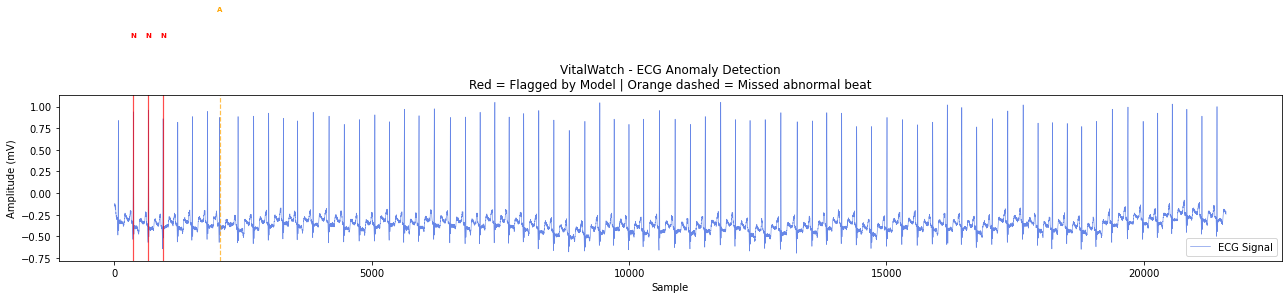

In [17]:
# Plot 60 seconds of ECG with flagged beats marked
window = 60 * fs  # 60 seconds of signal

plt.figure(figsize=(18, 5))
plt.plot(ecg_signal[:window], color='royalblue', linewidth=0.6, label='ECG Signal', alpha=0.8)

# Mark flagged anomalies in red
for _, row in feature_df.iterrows():
    if row['sample'] < window and row['anomaly_flag'] == 1:
        plt.axvline(x=row['sample'], color='red', alpha=0.7, linewidth=1.2)
        plt.text(row['sample'], 1.8, row['symbol'], fontsize=7, color='red', ha='center', fontweight='bold')

# Mark true abnormal beats in orange (so we can see what was missed)
for _, row in feature_df.iterrows():
    if row['sample'] < window and row['symbol'] != 'N':
        if row['anomaly_flag'] == 0:  # missed by model
            plt.axvline(x=row['sample'], color='orange', alpha=0.7, linewidth=1.2, linestyle='--')
            plt.text(row['sample'], 2.1, row['symbol'], fontsize=7, color='orange', ha='center', fontweight='bold')

plt.title('VitalWatch - ECG Anomaly Detection\n'
          'Red = Flagged by Model | Orange dashed = Missed abnormal beat')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.tight_layout()
plt.show()

### Key learning

VitalWatch has gone through 4 phases:

- Phase 1: Loaded and visualised real clinical ECG data (MIT-BIH)
- Phase 2: Engineered 3 core features from raw signal
- Phase 3: Baseline Isolation Forest model - 44.1% detection
- Phase 4: Enhanced model with 6 features - 52.9% detection

The visualisation above shows the model flagging beats directly on 
the ECG signal - red lines are model flags, orange dashed are missed 
true anomalies.

The gap between 52.9% and 100% represents the genuine difficulty 
of unsupervised anomaly detection on subtle cardiac rhythm changes.
This is an unsolved clinical problem, not a failure of the approach.